In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torchvision
import numpy as np
from tqdm import tqdm
from TextToConcept import TextToConcept
import my_utils

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/rodrigopaganini/master/xai/project/Text-to-concept/ViCLIP/viclip_text.py:4: UserWarning: pkg_res

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [3]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
from transformers import VideoMAEModel
from video_utils import VideoMAETTCTWrapper

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# feature_extractor = VideoMAEVideoProcessor.from_pretrained("MCG-NJU/videomae-small-finetuned-ssv2")  # TODO unnecessary??
videomae_model = VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
videomae_model = videomae_model.to(device)

model = VideoMAETTCTWrapper(videomae_model, normalizer=torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))

Loading weights: 100%|██████████| 184/184 [00:00<00:00, 12221.90it/s]
VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED |  | 
mask_token                                                           | UNEXPECTED |  | 
encoder_to_decoder.weight                                            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED | 

In [5]:
# text_to_concept = TextToConcept(model, model_name='resnet50', input_type='video')
text_to_concept = TextToConcept(model, model_name='videomae', input_type='video')

In [6]:
path = 'pretrained_aligners/videomae_base_aligner_k400.pth'
text_to_concept.load_linear_aligner(path, device='cpu')
text_to_concept.device = torch.device('cpu')

In [7]:
# dset_name = 'ssv2_val'
dset_name = 'k400_train'

In [8]:
import json
from pathlib import Path
from video_utils import load_ssv2_split, DivideBy255, CTHWToTCHW, ToTensorTuple
from train_video_aligner import SizedLabeledVideoDataset
from video_utils import load_k400_split, filter_labeled_video_paths_by_labels
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler

preprocessing_without_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

K400_ROOT = Path("dataset/k400")
K400_CLASSES_PATH = Path("dataset/k400/kinetics_classnames.json")

CLASSES_TO_KEEP = [
    "bowling",
    "chopping wood",
    "playing guitar",
    "playing piano",
    "riding a bike",
    "swimming backstroke",
]

with open(K400_CLASSES_PATH, 'r') as f:
    class_to_idx = json.load(f)
class_to_idx = {k.strip('"'): int(v) for k, v in class_to_idx.items()}

labeled_video_paths = load_k400_split(
    "train",
    K400_ROOT / "train/1",
    class_to_idx=class_to_idx
)

clip_sampler = UniformClipSampler(clip_duration=3.0)

subset_paths, map_old_to_new_index = filter_labeled_video_paths_by_labels(
    labeled_video_paths,
    allowed_labels=CLASSES_TO_KEEP,
    class_to_idx=class_to_idx
)

subset_class_names = [None] * len(map_old_to_new_index)
for class_name, old_idx in class_to_idx.items():
    if old_idx in map_old_to_new_index:
        subset_class_names[map_old_to_new_index[old_idx]] = class_name

dset = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

print(len(dset))
print(subset_class_names)


200
['bowling', 'chopping wood', 'playing guitar', 'playing piano', 'riding a bike', 'swimming backstroke']


# Load concept scores

In [9]:
# templates = ['itap of a {}', 'a bad photo of the {}', 'a origami {}', 'a photo of the large {}',
#              'a {} in a video game', 'art of the {}', 'a photo of the small {}']
templates = [
    'a video of someone {}',
    'a bad video of someone {}',
    'a video of someone clearly {}',
    'someone {} in a video',
]  # TODO prompt engineering

# Train CBM

In [10]:
text_to_concept.device = torch.device('mps')

In [11]:
text_to_concept.clip_model = text_to_concept.clip_model.to('mps')

In [12]:
import pandas as pd
from concept_bottleneck_model import ConceptBottleneckModel, CBMTrainer

concept_df = pd.read_csv('concept_prompts_viclip.csv')
concept_list = list(concept_df['prompt'])

mtype = 'videomae'
cbm = ConceptBottleneckModel(concept_list, subset_class_names, mtype)
trainer = CBMTrainer(cbm)
_ = cbm.embed_concepts(text_to_concept.clip_model.to('cpu').eval())

In [13]:
from pathlib import Path
import numpy as np
import torch

vision_names = np.load('data/reps_videomae_k400/representations_k400vision_model_reps_names.npy')
vision_reps = np.load('data/reps_videomae_k400/representations_k400vision_model_reps.npy')

name_to_label = {
    Path(video_path).stem: map_old_to_new_index[info["label"]]
    for video_path, info in dset._labeled_videos
}

matched_idx = np.array([
    i for i, name in enumerate(vision_names)
    if Path(str(name)).stem in name_to_label
])

subset_vision_names = vision_names[matched_idx]
subset_vision_reps = vision_reps[matched_idx]
labels = np.array(
    [name_to_label[Path(str(name)).stem] for name in subset_vision_names],
    dtype=np.int64,
)

aligned_subset_vision_reps = (
    text_to_concept.linear_aligner
    .get_aligned_representation(torch.from_numpy(subset_vision_reps).float().to('cpu'))
    .detach()
    .cpu()
    .numpy()
)

sims = cbm.get_concept_concept_scores(aligned_subset_vision_reps)

print(f"matched {len(subset_vision_names)} / {len(vision_names)} saved reps")
print(subset_vision_reps.shape, aligned_subset_vision_reps.shape, labels.shape)

matched 514 / 30660 saved reps
(514, 768) (514, 768) (514,)


/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: divide by zero encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: overflow encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: invalid value encountered in matmul
  scores = vision_features @ concept_embeddings.T


In [14]:
# from pathlib import Path

# name_to_label = {
#     Path(video_path).stem: map_old_to_new_index[info["label"]]
#     for video_path, info in dset._labeled_videos
# }

# labels = np.array([name_to_label[Path(name).stem.strip('.mp4')] for name in subset_vision_names])

In [15]:
trainer.train(concept_scores=sims, labels=labels, batch_size=8, epochs=100)

Training concept bottleneck ...
Linear projection: (26) --> (6).
Initial loss: 1.769
Epoch number, loss: 0, 1.759
Full-batch loss: 1.747
Epoch number, loss: 1, 1.741
Full-batch loss: 1.733
Epoch number, loss: 2, 1.725
Full-batch loss: 1.722
Epoch number, loss: 3, 1.719
Full-batch loss: 1.714
Epoch number, loss: 4, 1.711
Full-batch loss: 1.707
Epoch number, loss: 5, 1.708
Full-batch loss: 1.701
Epoch number, loss: 6, 1.696
Full-batch loss: 1.695
Epoch number, loss: 7, 1.691
Full-batch loss: 1.689
Epoch number, loss: 8, 1.688
Full-batch loss: 1.683
Epoch number, loss: 9, 1.681
Full-batch loss: 1.678
Epoch number, loss: 10, 1.683
Full-batch loss: 1.672
Epoch number, loss: 11, 1.673
Full-batch loss: 1.667
Epoch number, loss: 12, 1.662
Full-batch loss: 1.662
Epoch number, loss: 13, 1.663
Full-batch loss: 1.657
Epoch number, loss: 14, 1.652
Full-batch loss: 1.652
Epoch number, loss: 15, 1.650
Full-batch loss: 1.647
Epoch number, loss: 16, 1.644
Full-batch loss: 1.642
Epoch number, loss: 17, 

In [19]:
CLASSES_TO_KEEP

['bowling',
 'chopping wood',
 'playing guitar',
 'playing piano',
 'riding a bike',
 'swimming backstroke']

class: chopping wood
chosen idx: 8
video stem: 39zZgsn9K_I
video path: dataset/k400/train/1/chopping wood/39zZgsn9K_I.mp4

Top concept scores:
a video outdoors                              0.152
a video of an action requiring careful balance 0.151
a video of a forceful action                  0.139
a video of a person standing                  0.132
a video showing vertical movement             0.124
a video indoors                               0.115
a video of a person with an extended posture  0.114
a video of a person moving their whole body   0.107
a video of a person moving from one place to another 0.103
a video of a person manipulating an object    0.098

Class probabilities:
swimming backstroke  0.401
chopping wood        0.241
bowling              0.120
playing guitar       0.091
riding a bike        0.083
playing piano        0.064


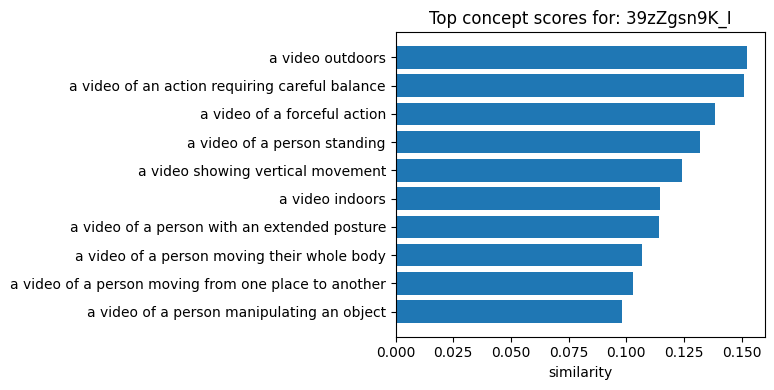

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


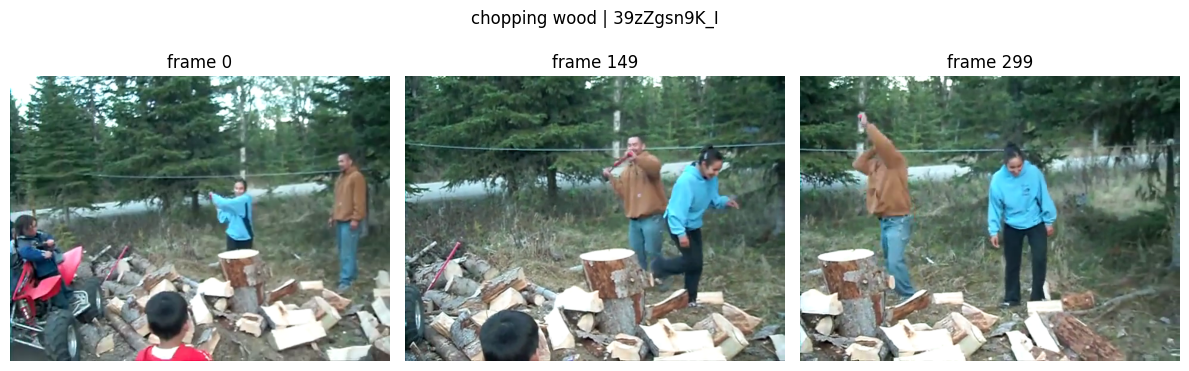

In [36]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

# TARGET_CLASS = "bowling"  # ish
TARGET_CLASS = "chopping wood"  # ish
# TARGET_CLASS = "playing guitar"  # proper
# TARGET_CLASS = "playing piano"  # ish
# TARGET_CLASS = "riding a bike"  # bad
# TARGET_CLASS = "swimming backstroke"  # GOOD
N_TOP_CONCEPTS = 10
N_FRAMES = 3
SEED = 42

rng = np.random.default_rng(SEED)

# Map class name -> class index
class_idx = subset_class_names.index(TARGET_CLASS)

# Pick one random matched example from that class
candidate_idx = np.where(labels == class_idx)[0]
chosen_idx = int(rng.choice(candidate_idx))

chosen_name = Path(str(subset_vision_names[chosen_idx])).stem
path_by_stem = {Path(video_path).stem: video_path for video_path, _ in dset._labeled_videos}
video_path = path_by_stem[chosen_name]

print("class:", TARGET_CLASS)
print("chosen idx:", chosen_idx)
print("video stem:", chosen_name)
print("video path:", video_path)

# Concept scores for this example
concept_scores = sims[chosen_idx]
top_idx = np.argsort(-concept_scores)[:N_TOP_CONCEPTS]

print("\nTop concept scores:")
for i in top_idx:
    print(f"{concept_list[i]:45s} {concept_scores[i]:.3f}")

# Optional: class probabilities from trained CBM
with torch.no_grad():
    x = torch.from_numpy(sims[chosen_idx:chosen_idx+1]).float().to(trainer.device)
    logits = trainer.model(x)
    probs = logits.softmax(dim=1).cpu().numpy()[0]

print("\nClass probabilities:")
for i in np.argsort(-probs):
    print(f"{subset_class_names[i]:20s} {probs[i]:.3f}")

# Plot top concept scores
plt.figure(figsize=(8, 4))
plt.barh([concept_list[i] for i in top_idx][::-1], concept_scores[top_idx][::-1])
plt.title(f"Top concept scores for: {chosen_name}")
plt.xlabel("similarity")
plt.tight_layout()
plt.show()

# Load full video and show evenly spaced frames
frames, _, info = torchvision.io.read_video(video_path, pts_unit="sec")
num_frames = len(frames)

frame_idx = np.linspace(0, num_frames - 1, N_FRAMES, dtype=int)

fig, axes = plt.subplots(1, N_FRAMES, figsize=(4 * N_FRAMES, 4))
if N_FRAMES == 1:
    axes = [axes]

for ax, fi in zip(axes, frame_idx):
    ax.imshow(frames[fi].numpy())
    ax.set_title(f"frame {fi}")
    ax.axis("off")

plt.suptitle(f"{TARGET_CLASS} | {chosen_name}")
plt.tight_layout()
plt.show()


### Test

In [16]:
import json
from pathlib import Path
from video_utils import load_ssv2_split, DivideBy255, CTHWToTCHW, ToTensorTuple
from train_video_aligner import SizedLabeledVideoDataset
from video_utils import load_k400_split, filter_labeled_video_paths_by_labels
from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey
from torchvision.transforms import Compose, Resize, CenterCrop
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler

preprocessing_without_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(16),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
        ]),
    ),
    ToTensorTuple(['video', 'label', 'video_name']),
])

K400_ROOT = Path("dataset/k400")
K400_CLASSES_PATH = Path("dataset/k400/kinetics_classnames.json")

with open(K400_CLASSES_PATH, 'r') as f:
    class_to_idx = json.load(f)
class_to_idx = {k.strip('"'): int(v) for k, v in class_to_idx.items()}

# labeled_video_paths = load_k400_split(
#     "test",
#     K400_ROOT / "test/1/videos_val",
#     class_to_idx=class_to_idx,
#     labels_path=Path(K400_ROOT / "test/1/kinetics400_val_list_videos.txt")
# )
labeled_video_paths = load_k400_split(
    "train",
    K400_ROOT / "train/1",
    class_to_idx=class_to_idx
)

subset_paths_test, test_old_to_new_index = filter_labeled_video_paths_by_labels(
    labeled_video_paths,
    allowed_labels=CLASSES_TO_KEEP,
    class_to_idx=class_to_idx
)

dset_test = SizedLabeledVideoDataset(
    video_sampler=torch.utils.data.SequentialSampler,
    labeled_video_paths=subset_paths_test,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

print(len(dset_test))
print(test_old_to_new_index == map_old_to_new_index)


200
True


In [33]:
import torch
import numpy as np
from pathlib import Path

test_name_to_label = {
    Path(video_path).stem: test_old_to_new_index[info["label"]]
    for video_path, info in dset_test._labeled_videos
}

test_vision_names = np.load('data/reps_videomae_k400/representations_k400vision_model_reps_names.npy')
test_vision_reps = np.load('data/reps_videomae_k400/representations_k400vision_model_reps.npy')

test_matched_idx = np.array([
    i for i, name in enumerate(test_vision_names)
    if Path(str(name)).stem in test_name_to_label
])

test_subset_vision_names = test_vision_names[test_matched_idx]
test_subset_vision_reps = test_vision_reps[test_matched_idx]
test_labels = np.array(
    [test_name_to_label[Path(str(name)).stem] for name in test_subset_vision_names],
    dtype=np.int64,
)

aligned_test_subset_vision_reps = (
    text_to_concept.linear_aligner
    .get_aligned_representation(torch.from_numpy(test_subset_vision_reps).float().to('cpu'))
    .detach()
    .cpu()
    .numpy()
)

test_sims = cbm.get_concept_concept_scores(aligned_test_subset_vision_reps)

loss, acc, y_true, y_pred = trainer.eval(
    concept_scores=test_sims,
    labels=test_labels,
    batch_size=256,
    return_preds=True,
)


/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: divide by zero encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: overflow encountered in matmul
  scores = vision_features @ concept_embeddings.T
/Users/rodrigopaganini/master/xai/project/Text-to-concept/concept_bottleneck_model.py:33: RuntimeWarning: invalid value encountered in matmul
  scores = vision_features @ concept_embeddings.T


Eval loss: 1.418
Eval acc: 0.471


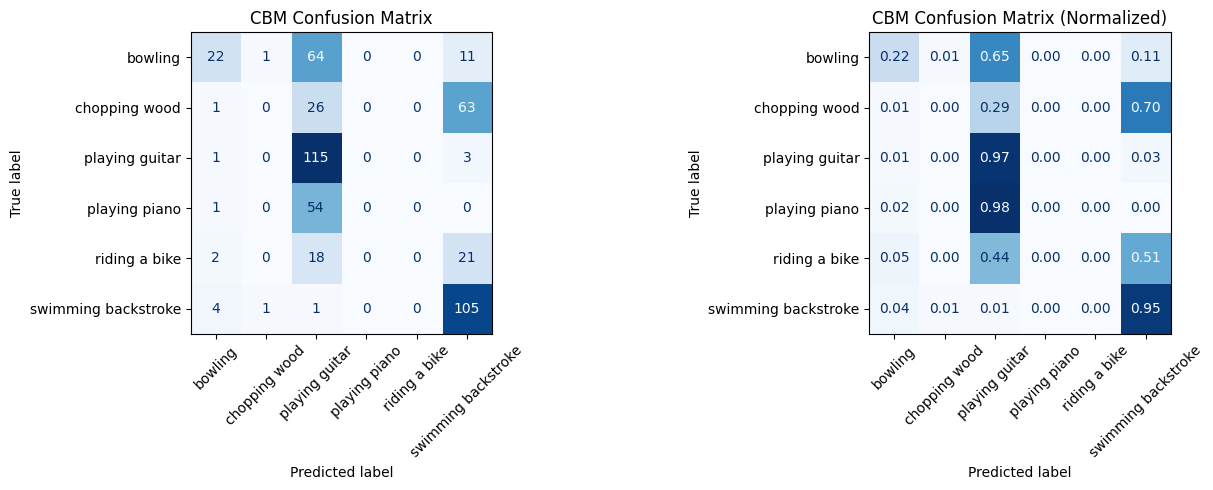

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=subset_class_names)
disp.plot(ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
axes[0].set_title("CBM Confusion Matrix")

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=subset_class_names)
disp_norm.plot(ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=False, values_format=".2f")
axes[1].set_title("CBM Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()
